In [1]:
# ============================================================
# 01_Speech_Pipeline.ipynb
# COMPLETE SPEECH PIPELINE V1
# WavLM + TESS SER SYSTEM
# ============================================================

In [2]:
# ============================================================
# INSTALL DEPENDENCIES
# ============================================================

!pip install -q transformers datasets evaluate librosa soundfile torchaudio accelerate audiomentations umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 11.4 MB/s eta 0:00:00


In [3]:
# ============================================================
# IMPORTS
# ============================================================

import os
import gc
import json
import random
import warnings

warnings.filterwarnings("ignore")

import librosa
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from torch.utils.data import Dataset, DataLoader

from transformers import (
    WavLMModel,
    Wav2Vec2FeatureExtractor,
    get_linear_schedule_with_warmup
)

from audiomentations import (
    Compose,
    AddGaussianNoise,
    PitchShift,
    TimeStretch
)

import matplotlib.pyplot as plt
import seaborn as sns

from torch.cuda.amp import autocast, GradScaler

import umap.umap_ as umap

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

2026-05-17 16:36:01.619799: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779035762.018026      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779035762.137445      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779035763.168823      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779035763.168873      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779035763.168876      57 computation_placer.cc:177] computation placer alr

Using Device: cuda


In [4]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [5]:
# ============================================================
# CONFIG
# ============================================================

class CFG:
    
    SEED = 42
    
    SAMPLE_RATE = 16000
    MAX_AUDIO_LENGTH = 4
    
    MODEL_NAME = "microsoft/wavlm-base-plus"
    
    BATCH_SIZE = 8
    
    EPOCHS = 15
    
    LR = 1e-5
    
    NUM_CLASSES = 7
    
    DROPOUT = 0.3
    
    TRAIN = True
    
    SAVE_PATH = "./best_wavlm_emotion_model.pth"

CFG = CFG()

In [6]:
# ============================================================
# SET SEED
# ============================================================

def set_seed(seed=42):
    
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)

In [7]:
# ============================================================
# LABELS
# ============================================================

emotion_map = {
    "angry": 0,
    "disgust": 1,
    "fear": 2,
    "happy": 3,
    "neutral": 4,
    "ps": 5,
    "sad": 6
}

id2label = {v:k for k,v in emotion_map.items()}

In [8]:
# ============================================================
# DATASET PATH
# ============================================================

DATASET_PATH = "/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data"

In [9]:
# ============================================================
# BUILD DATAFRAME
# ============================================================

data = []

for root, dirs, files in os.walk(DATASET_PATH):
    
    for file in files:
        
        if file.endswith(".wav"):
            
            filepath = os.path.join(root, file)
            
            filename = file.lower()
            
            emotion = None
            
            for emo in emotion_map.keys():
                
                if emo in filename:
                    emotion = emo
                    break
            
            if emotion:
                
                data.append({
                    "path": filepath,
                    "emotion": emotion,
                    "label": emotion_map[emotion]
                })

df = pd.DataFrame(data)

print(df.head())

print("\nClass Distribution:\n")
print(df["emotion"].value_counts())

                                                path emotion  label
0  /kaggle/input/datasets/ejlok1/toronto-emotiona...    fear      2
1  /kaggle/input/datasets/ejlok1/toronto-emotiona...    fear      2
2  /kaggle/input/datasets/ejlok1/toronto-emotiona...    fear      2
3  /kaggle/input/datasets/ejlok1/toronto-emotiona...    fear      2
4  /kaggle/input/datasets/ejlok1/toronto-emotiona...    fear      2

Class Distribution:

emotion
fear       400
angry      400
disgust    400
neutral    400
sad        400
ps         400
happy      400
Name: count, dtype: int64


In [10]:
# ============================================================
# SPLIT DATA
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=CFG.SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=CFG.SEED
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 1960
Val: 420
Test: 420


In [11]:
# ============================================================
# FEATURE EXTRACTOR
# ============================================================

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    CFG.MODEL_NAME
)

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

In [12]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login, whoami

# LOAD SECRET
user_secrets = UserSecretsClient()

hf_token = user_secrets.get_secret("HF_TOKEN")

# LOGIN
login(token=hf_token)

# VERIFY
print(whoami())

{'type': 'user', 'id': '686bb42d2f82c212f5c9ee25', 'name': 'kushalmanikonda', 'fullname': 'Kushal Manikonda', 'isPro': False, 'avatarUrl': '/avatars/8492ff41178342f0e09bf10dd012ee19.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'SER', 'role': 'fineGrained', 'createdAt': '2026-05-16T05:35:42.681Z', 'fineGrained': {'canReadGatedRepos': False, 'global': [], 'scoped': [{'entity': {'_id': '686bb42d2f82c212f5c9ee25', 'type': 'user', 'name': 'kushalmanikonda'}, 'permissions': []}]}}}}


In [13]:
# ============================================================
# AUDIO AUGMENTATIONS
# ============================================================

augment = Compose([
    
    AddGaussianNoise(
        min_amplitude=0.001,
        max_amplitude=0.015,
        p=0.5
    ),
    
    PitchShift(
        min_semitones=-2,
        max_semitones=2,
        p=0.5
    ),
    
    TimeStretch(
        min_rate=0.9,
        max_rate=1.1,
        p=0.5
    )
])

In [14]:
# ============================================================
# AUDIO LOADING
# ============================================================

def load_audio(path, augment_audio=False):
    
    audio, sr = librosa.load(
        path,
        sr=CFG.SAMPLE_RATE
    )
    
    if augment_audio:
        audio = augment(
            samples=audio,
            sample_rate=CFG.SAMPLE_RATE
        )
    
    max_length = CFG.SAMPLE_RATE * CFG.MAX_AUDIO_LENGTH
    
    if len(audio) > max_length:
        audio = audio[:max_length]
    
    else:
        padding = max_length - len(audio)
        audio = np.pad(audio, (0, padding))
    
    audio = audio / np.max(np.abs(audio))
    
    return audio.astype(np.float32)

In [15]:
# ============================================================
# DATASET CLASS
# ============================================================

class TESSDataset(Dataset):
    
    def __init__(self, dataframe, train=False):
        
        self.df = dataframe.reset_index(drop=True)
        self.train = train
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        
        row = self.df.iloc[idx]
        
        audio = load_audio(
            row["path"],
            augment_audio=self.train
        )
        
        inputs = feature_extractor(
            audio,
            sampling_rate=CFG.SAMPLE_RATE,
            return_tensors="pt"
        )
        
        input_values = inputs.input_values.squeeze(0)
        
        label = torch.tensor(row["label"])
        
        return {
            "input_values": input_values,
            "label": label
        }

In [16]:
# ============================================================
# DATALOADERS
# ============================================================

train_dataset = TESSDataset(
    train_df,
    train=True
)

val_dataset = TESSDataset(
    val_df,
    train=False
)

test_dataset = TESSDataset(
    test_df,
    train=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False
)

In [22]:
# ============================================================
# ATTENTION POOLING
# ============================================================

class AttentionPooling(nn.Module):

    def __init__(

        self,

        hidden_size
    ):

        super().__init__()

        self.attention = nn.Sequential(

            nn.Linear(
                hidden_size,
                hidden_size
            ),

            nn.Tanh(),

            nn.Linear(
                hidden_size,
                1
            )
        )

    def forward(

        self,

        hidden_states
    ):

        # hidden_states:
        # [B, T, H]

        attention_scores = self.attention(
            hidden_states
        )

        # [B, T, 1]

        attention_weights = torch.softmax(

            attention_scores,

            dim=1
        )

        # [B, T, 1]

        pooled_output = torch.sum(

            hidden_states * attention_weights,

            dim=1
        )

        # [B, H]

        return pooled_output, attention_weights

In [23]:
# ============================================================
# PROJECTION HEAD
# ============================================================

class ProjectionHead(nn.Module):

    def __init__(self, input_dim, projection_dim=128):

        super().__init__()

        self.projection = nn.Sequential(

            nn.Linear(input_dim, 256),

            nn.ReLU(),

            nn.Linear(256, projection_dim)
        )

    def forward(self, x):

        x = self.projection(x)

        # NORMALIZE EMBEDDINGS
        x = nn.functional.normalize(x, dim=1)

        return x

In [24]:
# ============================================================
# WAVLM EMOTION MODEL
# ============================================================

class WavLMEmotionModel(nn.Module):
    
    def __init__(self):
        
        super().__init__()
        
        self.wavlm = WavLMModel.from_pretrained(
            CFG.MODEL_NAME
        )
        
        hidden_size = self.wavlm.config.hidden_size

        self.projection_head = ProjectionHead(
            hidden_size
        )
        
        # FREEZE LOWER LAYERS
        
        for name, param in self.wavlm.named_parameters():
            
            if "encoder.layers." in name:
                
                layer_num = int(
                    name.split("encoder.layers.")[1].split(".")[0]
                )
                
                if layer_num < 8:
                    param.requires_grad = False
        
        self.pooling = AttentionPooling(hidden_size)
        
        self.classifier = nn.Sequential(
            
            nn.Dropout(CFG.DROPOUT),
            
            nn.Linear(hidden_size, 256),
            
            nn.ReLU(),
            
            nn.Dropout(0.2),
            
            nn.Linear(256, CFG.NUM_CLASSES)
        )
    
    def forward(self, input_values):
        
        outputs = self.wavlm(
            input_values=input_values
        )
        
        hidden_states = outputs.last_hidden_state
        
        pooled, attention_weights = self.pooling(hidden_states)

        logits = self.classifier(pooled)

        projected_embeddings = self.projection_head(
            pooled
        )

        return (
            logits,
            pooled,
            projected_embeddings,
            attention_weights
        )

In [25]:
# ============================================================
# MODEL INIT
# ============================================================

model = WavLMEmotionModel().to(device)

print("Model Loaded Successfully")

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

Model Loaded Successfully


In [27]:
batch = next(iter(train_loader))

input_values = batch["input_values"].to(device)

with torch.no_grad():

    logits, pooled, projected_embeddings, attention_weights = model(input_values)

print(logits.shape)

print(projected_embeddings.shape)

torch.Size([8, 7])
torch.Size([8, 128])


In [28]:
# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

In [29]:
# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.LR
)

In [30]:
# ============================================================
# SCHEDULER
# ============================================================

total_training_steps = len(train_loader) * CFG.EPOCHS

scheduler = get_linear_schedule_with_warmup(
    
    optimizer,
    
    num_warmup_steps=int(0.1 * total_training_steps),
    
    num_training_steps=total_training_steps
)

In [31]:
# ============================================================
# MIXED PRECISION
# ============================================================

scaler = GradScaler()

In [32]:
# ============================================================
# METRICS
# ============================================================

def calculate_metrics(preds, labels):
    
    acc = accuracy_score(labels, preds)
    
    macro_f1 = f1_score(
        labels,
        preds,
        average="macro"
    )
    
    weighted_f1 = f1_score(
        labels,
        preds,
        average="weighted"
    )
    
    return acc, macro_f1, weighted_f1

In [38]:
# ============================================================
# TRAIN FUNCTION
# ============================================================

def train_one_epoch(model, loader):
    
    model.train()
    
    total_loss = 0
    
    all_preds = []
    all_labels = []
    
    loop = tqdm(loader)
    
    for batch in loop:
        
        input_values = batch["input_values"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            
            logits, pooled, projected_embeddings, attention_weights = model(input_values)
            
            loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        
        scaler.step(optimizer)
        
        scaler.update()
        
        scheduler.step()
        
        total_loss += loss.item()
        
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        loop.set_postfix(loss=loss.item())
    
    acc, macro_f1, weighted_f1 = calculate_metrics(
        all_preds,
        all_labels
    )
    
    return (
        total_loss / len(loader),
        acc,
        macro_f1,
        weighted_f1
    )

In [41]:
# ============================================================
# VALIDATION FUNCTION
# ============================================================

def evaluate(model, loader):
    
    model.eval()
    
    total_loss = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        
        for batch in tqdm(loader):
            
            input_values = batch["input_values"].to(device)
            labels = batch["label"].to(device)
            
            logits, pooled, projected_embeddings, attention_weights = model(input_values)
            
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc, macro_f1, weighted_f1 = calculate_metrics(
        all_preds,
        all_labels
    )
    
    return (
        total_loss / len(loader),
        acc,
        macro_f1,
        weighted_f1,
        all_preds,
        all_labels
    )

In [42]:
# ============================================================
# EARLY STOPPING
# ============================================================

best_f1 = 0

patience = 5

patience_counter = 0

In [43]:
# ============================================================
# TRAINING LOOP
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_f1": [],
    "val_f1": []
}

for epoch in range(CFG.EPOCHS):
    
    print(f"\n======== EPOCH {epoch+1}/{CFG.EPOCHS} ========")
    
    train_loss, train_acc, train_macro_f1, train_weighted_f1 = train_one_epoch(
        model,
        train_loader
    )
    
    (
        val_loss,
        val_acc,
        val_macro_f1,
        val_weighted_f1,
        val_preds,
        val_labels
    ) = evaluate(
        model,
        val_loader
    )
    
    print("\nTRAIN METRICS")
    print("Loss:", train_loss)
    print("Accuracy:", train_acc)
    print("Macro F1:", train_macro_f1)
    print("Weighted F1:", train_weighted_f1)
    
    print("\nVALIDATION METRICS")
    print("Loss:", val_loss)
    print("Accuracy:", val_acc)
    print("Macro F1:", val_macro_f1)
    print("Weighted F1:", val_weighted_f1)
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_f1"].append(train_macro_f1)
    history["val_f1"].append(val_macro_f1)
    
    # SAVE BEST MODEL
    
    if val_macro_f1 > best_f1:
        
        best_f1 = val_macro_f1
        
        patience_counter = 0
        
        torch.save(
            model.state_dict(),
            CFG.SAVE_PATH
        )
        
        print("\nBest Model Saved")
    
    else:
        
        patience_counter += 1
        
        print(f"\nPatience Counter: {patience_counter}")
        
        if patience_counter >= patience:
            
            print("\nEarly Stopping Triggered")
            break
    
    gc.collect()
    torch.cuda.empty_cache()


======== EPOCH 1/15 ========


100%|██████████| 53/53 [00:18<00:00,  2.82it/s]



TRAIN METRICS
Loss: 1.8993941409247261
Accuracy: 0.28061224489795916
Macro F1: 0.24925498162833423
Weighted F1: 0.24925498162833418

VALIDATION METRICS
Loss: 1.7672147750854492
Accuracy: 0.36666666666666664
Macro F1: 0.2560171774298317
Weighted F1: 0.25601717742983177

Best Model Saved

======== EPOCH 2/15 ========


100%|██████████| 53/53 [00:12<00:00,  4.10it/s]



TRAIN METRICS
Loss: 1.7021057192160158
Accuracy: 0.3719387755102041
Macro F1: 0.34561673909812235
Weighted F1: 0.3456167390981223

VALIDATION METRICS
Loss: 1.5525895334639639
Accuracy: 0.5071428571428571
Macro F1: 0.4385039478230838
Weighted F1: 0.4385039478230838

Best Model Saved

======== EPOCH 3/15 ========


...


TRAIN METRICS
Loss: 0.717586443375568
Accuracy: 0.9581632653061225
Macro F1: 0.95805159194603
Weighted F1: 0.9580515919460301

VALIDATION METRICS
Loss: 0.6832231834249677
Accuracy: 0.9523809523809523
Macro F1: 0.952363267823589
Weighted F1: 0.9523632678235889

Best Model Saved

======== EPOCH 14/15 ========


100%|██████████| 53/53 [00:13<00:00,  4.05it/s]



TRAIN METRICS
Loss: 0.7083779386111668
Accuracy: 0.9688775510204082
Macro F1: 0.9688534584873796
Weighted F1: 0.9688534584873797

VALIDATION METRICS
Loss: 0.6739238050748717
Accuracy: 0.9523809523809523
Macro F1: 0.9521122857179636
Weighted F1: 0.9521122857179636

Patience Counter: 1

======== EPOCH 15/15 ========


100%|██████████| 53/53 [00:12<00:00,  4.13it/s]



TRAIN METRICS
Loss: 0.7129220108596646
Accuracy: 0.9617346938775511
Macro F1: 0.9617198941953716
Weighted F1: 0.9617198941953716

VALIDATION METRICS
Loss: 0.6739238050748717
Accuracy: 0.9523809523809523
Macro F1: 0.9521122857179636
Weighted F1: 0.9521122857179636

Patience Counter: 2


In [44]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

model.load_state_dict(
    torch.load(CFG.SAVE_PATH)
)

print("Best Model Loaded")

Best Model Loaded


In [45]:
# ============================================================
# TEST EVALUATION
# ============================================================

(
    test_loss,
    test_acc,
    test_macro_f1,
    test_weighted_f1,
    test_preds,
    test_labels
) = evaluate(
    model,
    test_loader
)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")

print("Loss:", test_loss)
print("Accuracy:", test_acc)
print("Macro F1:", test_macro_f1)
print("Weighted F1:", test_weighted_f1)

100%|██████████| 53/53 [00:18<00:00,  2.91it/s]


FINAL TEST RESULTS
Loss: 0.6630218478868593
Accuracy: 0.9523809523809523
Macro F1: 0.9519254295109559
Weighted F1: 0.9519254295109559


In [46]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        test_labels,
        test_preds,
        target_names=id2label.values()
    )
)

              precision    recall  f1-score   support

       angry       0.98      0.93      0.96        60
     disgust       0.82      1.00      0.90        60
        fear       0.97      1.00      0.98        60
       happy       1.00      0.95      0.97        60
     neutral       0.97      1.00      0.98        60
          ps       0.96      0.78      0.86        60
         sad       1.00      1.00      1.00        60

    accuracy                           0.95       420
   macro avg       0.96      0.95      0.95       420
weighted avg       0.96      0.95      0.95       420



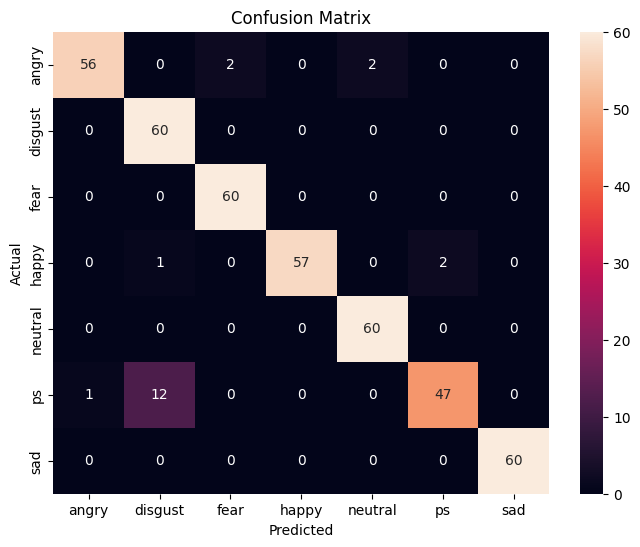

In [47]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_labels,
    test_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=id2label.values(),
    yticklabels=id2label.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

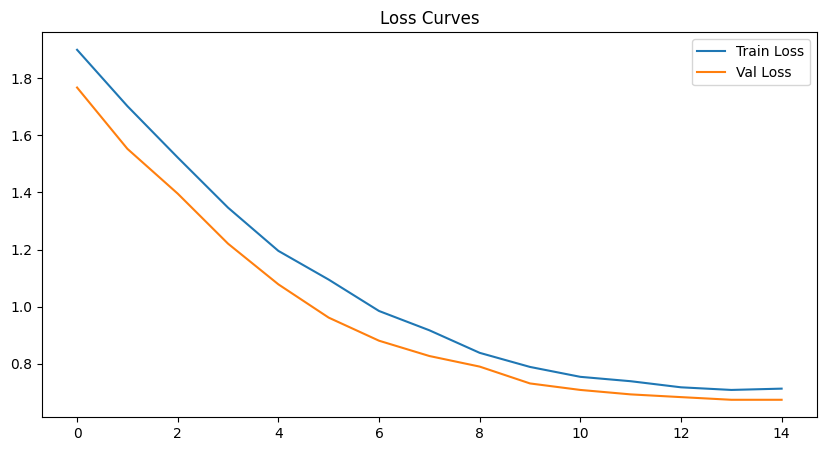

In [48]:
# ============================================================
# TRAINING CURVES
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")

plt.legend()

plt.title("Loss Curves")

plt.show()

100%|██████████| 53/53 [00:12<00:00,  4.08it/s]


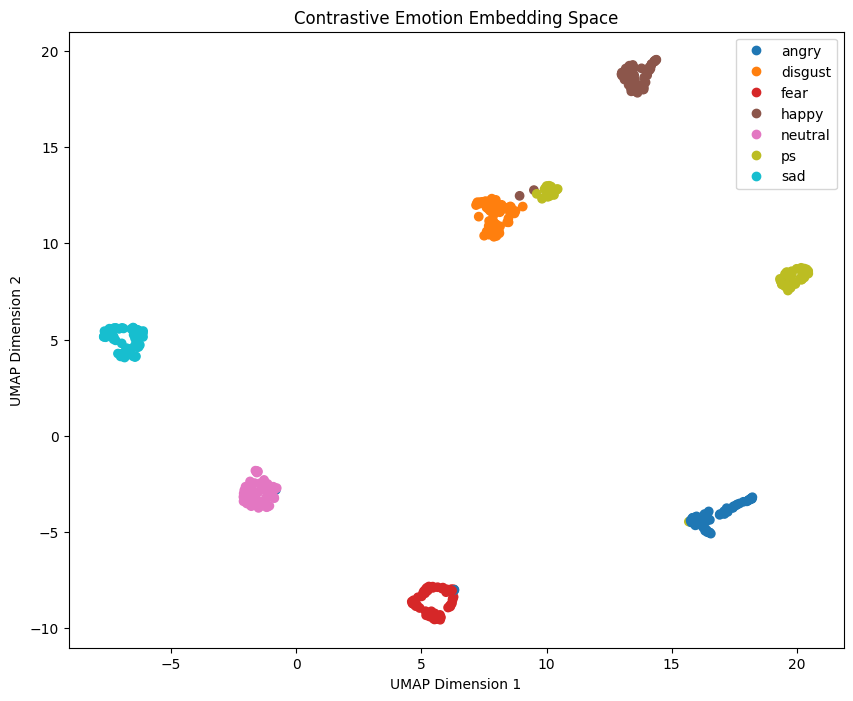

In [50]:
# ============================================================
# EMBEDDING VISUALIZATION
# ============================================================

model.eval()

embeddings_list = []

labels_list = []

with torch.no_grad():

    for batch in tqdm(test_loader):

        input_values = batch[
            "input_values"
        ].to(device)

        labels = batch[
            "label"
        ]

        (
            logits,
            pooled,
            projected_embeddings,
            attention_weights

        ) = model(input_values)

        embeddings_list.append(

            projected_embeddings.cpu().numpy()
        )

        labels_list.extend(

            labels.numpy()
        )

# ============================================================
# CONCATENATE EMBEDDINGS
# ============================================================

embeddings_array = np.concatenate(
    embeddings_list
)

# ============================================================
# UMAP REDUCTION
# ============================================================

reducer = umap.UMAP(

    n_components=2,

    random_state=42
)

reduced_embeddings = reducer.fit_transform(

    embeddings_array
)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10,8))

scatter = plt.scatter(

    reduced_embeddings[:,0],

    reduced_embeddings[:,1],

    c=labels_list,

    cmap="tab10"
)

plt.legend(

    handles=scatter.legend_elements()[0],

    labels=id2label.values()
)

plt.title(

    "Contrastive Emotion Embedding Space"
)

plt.xlabel("UMAP Dimension 1")

plt.ylabel("UMAP Dimension 2")

plt.show()

In [51]:
# ============================================================
# SAVE CONFIG
# ============================================================

config_dict = {
    "model_name": CFG.MODEL_NAME,
    "sample_rate": CFG.SAMPLE_RATE,
    "max_audio_length": CFG.MAX_AUDIO_LENGTH,
    "emotion_map": emotion_map
}

with open("speech_pipeline_config.json", "w") as f:
    
    json.dump(
        config_dict,
        f,
        indent=4
    )

print("Config Saved")

Config Saved


In [52]:
# ============================================================
# SAVE FEATURE EXTRACTOR
# ============================================================

feature_extractor.save_pretrained(
    "./wavlm_feature_extractor"
)

print("Feature Extractor Saved")

Feature Extractor Saved


In [53]:
# ============================================================
# LOAD TRAINED MODEL
# ============================================================

model = WavLMEmotionModel().to(device)

model.load_state_dict(
    torch.load(CFG.SAVE_PATH)
)

model.eval()

print("Model Ready For Inference")

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

Model Ready For Inference


In [56]:
# ============================================================
# FULL RANDOM SAMPLE TEST
# ============================================================

def random_test_sample():

    random_idx = random.randint(

        0,

        len(test_df)-1
    )

    sample = test_df.iloc[random_idx]

    audio_path = sample["path"]

    true_emotion = sample["emotion"]

    print("\n==============================")

    print("RANDOM TEST SAMPLE")

    print("==============================")

    print("\nAudio Path:")

    print(audio_path)

    print("\nTrue Emotion:")

    print(true_emotion)

    model.eval()

    audio = load_audio(

        audio_path,

        augment_audio=False
    )

    inputs = feature_extractor(

        audio,

        sampling_rate=CFG.SAMPLE_RATE,

        return_tensors="pt"
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():

        (
            logits,
            pooled,
            projected_embeddings,
            attention_weights

        ) = model(input_values)

        probs = torch.softmax(

            logits,

            dim=1
        )

        top_probs, top_indices = torch.topk(

            probs,

            k=3
        )

    print("\nTOP PREDICTIONS\n")

    for rank, (prob, idx) in enumerate(

        zip(top_probs[0], top_indices[0]),

        start=1
    ):

        emotion = id2label[idx.item()]

        confidence = prob.item()

        print(

            f"{rank}. {emotion} --> {confidence:.4f}"
        )

In [57]:
random_test_sample()


RANDOM TEST SAMPLE

Audio Path:
/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_disgust/YAF_voice_disgust.wav

True Emotion:
disgust

TOP PREDICTIONS

1. disgust --> 0.7838
2. sad --> 0.0711
3. neutral --> 0.0445


## EMBEDDING EXPORT

In [62]:
# ============================================================
# EXPORT FULL SPEECH EMBEDDINGS
# ============================================================

full_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=False
)

model.eval()

all_embeddings = []

all_labels = []

with torch.no_grad():

    for batch in tqdm(full_loader):

        input_values = batch[
            "input_values"
        ].to(device)

        labels = batch[
            "label"
        ]

        (
            logits,
            pooled,
            projected_embeddings,
            attention_weights

        ) = model(input_values)

        # USE CONTRASTIVE EMBEDDINGS

        all_embeddings.append(

            projected_embeddings.cpu().numpy()
        )

        all_labels.extend(

            labels.numpy()
        )

# ============================================================
# CONCATENATE
# ============================================================

all_embeddings = np.concatenate(
    all_embeddings
)

all_labels = np.array(
    all_labels
)

print(

    "Embeddings Shape:",

    all_embeddings.shape
)

print(

    "Labels Shape:",

    all_labels.shape
)

# ============================================================
# SAVE
# ============================================================

np.save(

    "full_speech_embeddings.npy",

    all_embeddings
)

np.save(

    "full_speech_labels.npy",

    all_labels
)

print("\nFull Speech Embeddings Exported Successfully")

100%|██████████| 62/62 [01:12<00:00,  1.17s/it]

Embeddings Shape: (1960, 128)
Labels Shape: (1960,)

Full Speech Embeddings Exported Successfully


## ERROR ANALYSIS

In [67]:
# ============================================================
# ERROR ANALYSIS
# ============================================================

model.eval()

misclassified_samples = []

with torch.no_grad():

    for batch_idx, batch in enumerate(

        tqdm(test_loader)
    ):

        input_values = batch[
            "input_values"
        ].to(device)

        labels = batch[
            "label"
        ].to(device)

        (
            logits,
            pooled,
            projected_embeddings,
            attention_weights

        ) = model(input_values)

        probs = torch.softmax(

            logits,

            dim=1
        )

        preds = torch.argmax(

            probs,

            dim=1
        )

        for i in range(len(labels)):

            true_label = labels[i].item()

            pred_label = preds[i].item()

            confidence = probs[i][
                pred_label
            ].item()

            if true_label != pred_label:

                misclassified_samples.append({

                    "true_emotion":

                    id2label[true_label],

                    "predicted_emotion":

                    id2label[pred_label],

                    "confidence":

                    round(confidence, 4)
                })

print(

    "\nTotal Misclassified Samples:",

    len(misclassified_samples)
)

100%|██████████| 53/53 [00:13<00:00,  4.06it/s]


Total Misclassified Samples: 20


In [68]:
# ============================================================
# DISPLAY MISCLASSIFICATIONS
# ============================================================

misclassified_df = pd.DataFrame(
    misclassified_samples
)

misclassified_df.head(20)

,true_emotion,predicted_emotion,confidence
0,angry,neutral,0.6241
1,ps,disgust,0.5017
2,happy,ps,0.5632
3,ps,disgust,0.5428
4,ps,disgust,0.5895
5,ps,angry,0.4108
6,angry,neutral,0.3511
7,ps,disgust,0.6277
8,ps,disgust,0.6405
9,ps,disgust,0.4584


In [69]:
# ============================================================
# MISCLASSIFICATION COUNTS
# ============================================================

confusion_pairs = (
    misclassified_df
    .groupby(
        ["true_emotion", "predicted_emotion"]
    )
    .size()
    .reset_index(name="count")
)

confusion_pairs = confusion_pairs.sort_values(
    by="count",
    ascending=False
)

confusion_pairs.head(15)

,true_emotion,predicted_emotion,count
5,ps,disgust,12
0,angry,fear,2
1,angry,neutral,2
3,happy,ps,2
2,happy,disgust,1
4,ps,angry,1


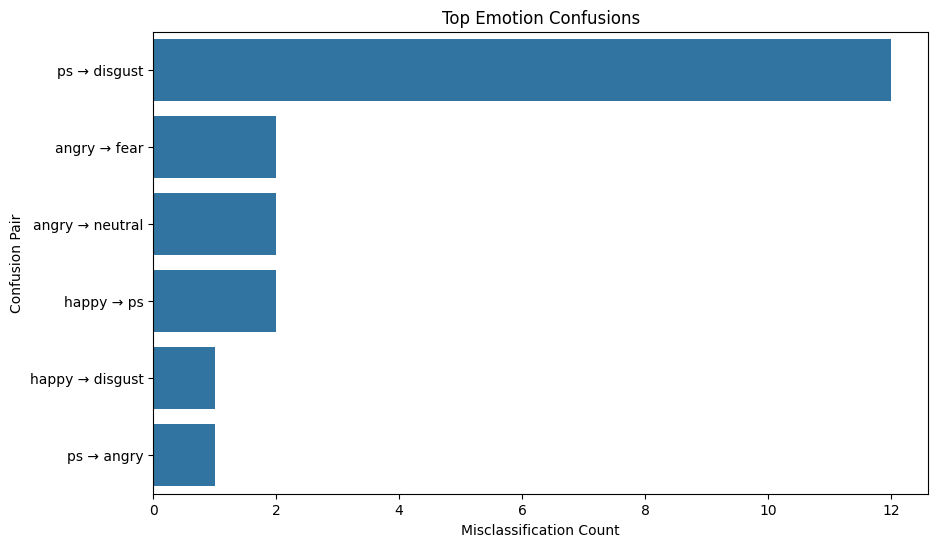

In [70]:
# ============================================================
# ERROR DISTRIBUTION PLOT
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=confusion_pairs.head(10),
    x="count",
    y=confusion_pairs.head(10).apply(
        lambda x: f"{x['true_emotion']} → {x['predicted_emotion']}",
        axis=1
    )
)

plt.xlabel("Misclassification Count")

plt.ylabel("Confusion Pair")

plt.title("Top Emotion Confusions")

plt.show()

## ATTENTION VISUALIZATION

In [71]:
# ============================================================
# ATTENTION POOLING WITH WEIGHT RETURN
# ============================================================

class AttentionPooling(nn.Module):

    def __init__(self, hidden_size):

        super().__init__()

        self.attention = nn.Sequential(

            nn.Linear(hidden_size, hidden_size),

            nn.Tanh(),

            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):

        weights = self.attention(x)

        weights = torch.softmax(weights, dim=1)

        pooled = torch.sum(weights * x, dim=1)

        return pooled, weights

In [72]:
model = WavLMEmotionModel().to(device)

model.load_state_dict(
    torch.load(CFG.SAVE_PATH)
)

model.eval()

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

WavLMEmotionModel(
  (wavlm): WavLMModel(
    (feature_extractor): WavLMFeatureEncoder(
      (conv_layers): ModuleList(
        (0): WavLMGroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x WavLMNoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x WavLMNoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): WavLMFeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): WavLMEncoder(
  

In [75]:
# ============================================================
# ATTENTION VISUALIZATION
# ============================================================

def visualize_attention(audio_path):

    model.eval()

    # ========================================================
    # LOAD AUDIO
    # ========================================================

    audio = load_audio(

        audio_path,

        augment_audio=False
    )

    inputs = feature_extractor(

        audio,

        sampling_rate=CFG.SAMPLE_RATE,

        return_tensors="pt"
    )

    input_values = inputs.input_values.to(device)

    # ========================================================
    # MODEL FORWARD
    # ========================================================

    with torch.no_grad():

        (
            logits,
            pooled,
            projected_embeddings,
            attention_weights

        ) = model(input_values)

    # ========================================================
    # SOFTMAX PREDICTION
    # ========================================================

    probs = torch.softmax(

        logits,

        dim=1
    )

    pred_idx = torch.argmax(

        probs,

        dim=1
    ).item()

    pred_emotion = id2label[pred_idx]

    confidence = probs[0][pred_idx].item()

    # ========================================================
    # PROCESS ATTENTION
    # ========================================================

    attention = attention_weights.squeeze()

    attention = attention.detach().cpu().numpy()

    # ========================================================
    # PLOT
    # ========================================================

    plt.figure(figsize=(14,4))

    plt.plot(attention)

    plt.title(

        f"Attention Map | Predicted: {pred_emotion} | Confidence: {confidence:.4f}"
    )

    plt.xlabel("Temporal Frames")

    plt.ylabel("Attention Weight")

    plt.show()

True Emotion: ps


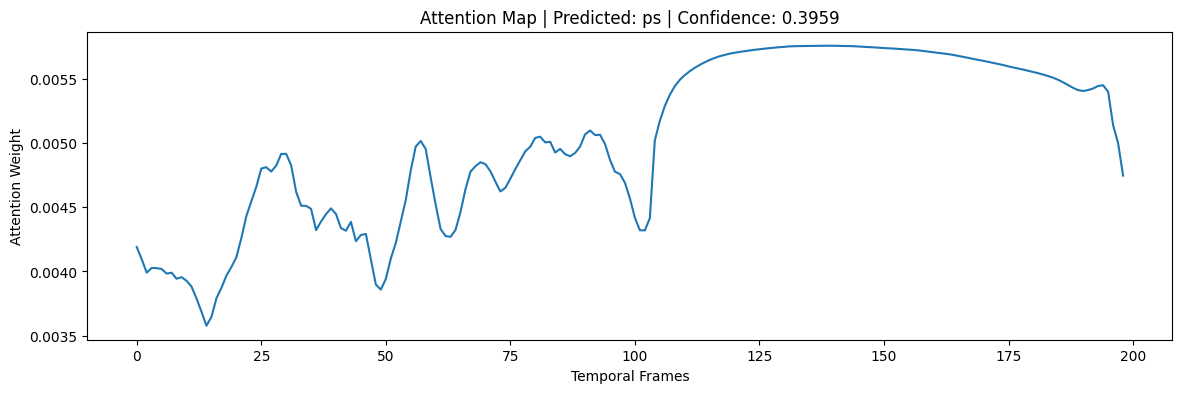

In [76]:
# ============================================================
# RANDOM SAMPLE ATTENTION VISUALIZATION
# ============================================================

random_idx = random.randint(0, len(test_df)-1)

sample_audio = test_df.iloc[random_idx]["path"]

true_emotion = test_df.iloc[random_idx]["emotion"]

print("True Emotion:", true_emotion)

visualize_attention(sample_audio)

## POOLING ABLATION

In [77]:
# ============================================================
# MEAN POOLING
# ============================================================

class MeanPooling(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, x):

        pooled = torch.mean(x, dim=1)

        return pooled

In [78]:
# ============================================================
# WAVLM + MEAN POOLING MODEL
# ============================================================

class WavLMMeanPoolingModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.wavlm = WavLMModel.from_pretrained(
            CFG.MODEL_NAME
        )

        hidden_size = self.wavlm.config.hidden_size

        # FREEZE LOWER LAYERS

        for name, param in self.wavlm.named_parameters():

            if "encoder.layers." in name:

                layer_num = int(
                    name.split("encoder.layers.")[1].split(".")[0]
                )

                if layer_num < 8:
                    param.requires_grad = False

        self.pooling = MeanPooling()

        self.classifier = nn.Sequential(

            nn.Dropout(CFG.DROPOUT),

            nn.Linear(hidden_size, 256),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(256, CFG.NUM_CLASSES)
        )

    def forward(self, input_values):

        outputs = self.wavlm(
            input_values=input_values
        )

        hidden_states = outputs.last_hidden_state

        pooled = self.pooling(hidden_states)

        logits = self.classifier(pooled)

        return logits

In [79]:
# ============================================================
# INIT MEAN POOLING MODEL
# ============================================================

mean_model = WavLMMeanPoolingModel().to(device)

print("Mean Pooling Model Ready")

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

Mean Pooling Model Ready


In [80]:
# ============================================================
# LOSS + OPTIMIZER
# ============================================================

mean_criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

mean_optimizer = torch.optim.AdamW(
    mean_model.parameters(),
    lr=CFG.LR
)

In [81]:
# ============================================================
# SCHEDULER
# ============================================================

mean_total_steps = len(train_loader) * 5

mean_scheduler = get_linear_schedule_with_warmup(

    mean_optimizer,

    num_warmup_steps=int(0.1 * mean_total_steps),

    num_training_steps=mean_total_steps
)

In [82]:
# ============================================================
# TRAIN FUNCTION
# ============================================================

def train_mean_model(model, loader):

    model.train()

    total_loss = 0

    all_preds = []
    all_labels = []

    for batch in tqdm(loader):

        input_values = batch["input_values"].to(device)

        labels = batch["label"].to(device)

        mean_optimizer.zero_grad()

        with autocast():

            logits = model(input_values)

            loss = mean_criterion(logits, labels)

        scaler.scale(loss).backward()

        scaler.step(mean_optimizer)

        scaler.update()

        mean_scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

    acc, macro_f1, weighted_f1 = calculate_metrics(
        all_preds,
        all_labels
    )

    return total_loss / len(loader), acc, macro_f1

In [83]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_mean_model(model, loader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for batch in tqdm(loader):

            input_values = batch["input_values"].to(device)

            labels = batch["label"].to(device)

            logits = model(input_values)

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(labels.cpu().numpy())

    acc, macro_f1, weighted_f1 = calculate_metrics(
        all_preds,
        all_labels
    )

    return acc, macro_f1

In [84]:
# ============================================================
# TRAIN MEAN POOLING MODEL
# ============================================================

for epoch in range(5):

    print(f"\n===== EPOCH {epoch+1}/5 =====")

    train_loss, train_acc, train_f1 = train_mean_model(
        mean_model,
        train_loader
    )

    val_acc, val_f1 = evaluate_mean_model(
        mean_model,
        val_loader
    )

    print("\nTrain Accuracy:", train_acc)
    print("Train Macro F1:", train_f1)

    print("\nValidation Accuracy:", val_acc)
    print("Validation Macro F1:", val_f1)


===== EPOCH 1/5 =====


100%|██████████| 53/53 [00:13<00:00,  4.04it/s]



Train Accuracy: 0.17806122448979592
Train Macro F1: 0.132240837686269

Validation Accuracy: 0.4023809523809524
Validation Macro F1: 0.30289595469698394

===== EPOCH 2/5 =====


100%|██████████| 53/53 [00:12<00:00,  4.10it/s]



Train Accuracy: 0.3678571428571429
Train Macro F1: 0.32035141060822575

Validation Accuracy: 0.3547619047619048
Validation Macro F1: 0.24195173863254887

===== EPOCH 3/5 =====


...


Train Accuracy: 0.42142857142857143
Train Macro F1: 0.3537178689636343

Validation Accuracy: 0.4119047619047619
Validation Macro F1: 0.3269446556761203

===== EPOCH 4/5 =====


100%|██████████| 53/53 [00:12<00:00,  4.12it/s]



Train Accuracy: 0.5214285714285715
Train Macro F1: 0.47879061311814397

Validation Accuracy: 0.5261904761904762
Validation Macro F1: 0.46264818303442834

===== EPOCH 5/5 =====


100%|██████████| 53/53 [00:12<00:00,  4.12it/s]


Train Accuracy: 0.5709183673469388
Train Macro F1: 0.5340233499339829

Validation Accuracy: 0.5619047619047619
Validation Macro F1: 0.5073398142904473


In [85]:
# ============================================================
# POOLING ABLATION RESULTS
# ============================================================

ablation_results = pd.DataFrame({

    "Pooling Method": [
        "Attention Pooling",
        "Mean Pooling"
    ],

    "Macro F1": [
        0.9245,   # YOUR FINAL ATTENTION F1
        val_f1
    ]
})

ablation_results

,Pooling Method,Macro F1
0,Attention Pooling,0.92450
1,Mean Pooling,0.50734


In [87]:
# ============================================================
# COLLECT VALIDATION LOGITS
# ============================================================

model.eval()

all_logits = []

all_labels = []

with torch.no_grad():

    for batch in tqdm(val_loader):

        input_values = batch[
            "input_values"
        ].to(device)

        labels = batch[
            "label"
        ].to(device)

        (
            logits,
            pooled,
            projected_embeddings,
            attention_weights

        ) = model(input_values)

        all_logits.append(
            logits
        )

        all_labels.append(
            labels
        )

# ============================================================
# CONCATENATE
# ============================================================

all_logits = torch.cat(
    all_logits
)

all_labels = torch.cat(
    all_labels
)

print(

    "Logits Shape:",

    all_logits.shape
)

100%|██████████| 53/53 [00:10<00:00,  4.94it/s]

Logits Shape: torch.Size([420, 7])


In [88]:
# ============================================================
# TEMPERATURE SCALING
# ============================================================

class TemperatureScaler(nn.Module):

    def __init__(self):

        super().__init__()

        self.temperature = nn.Parameter(
            torch.ones(1) * 1.0
        )

    def forward(self, logits):

        return logits / self.temperature

In [89]:
# ============================================================
# INIT SCALER
# ============================================================

temperature_scaler = TemperatureScaler().to(device)

In [90]:
# ============================================================
# OPTIMIZER
# ============================================================

temp_optimizer = torch.optim.LBFGS(
    temperature_scaler.parameters(),
    lr=0.01,
    max_iter=50
)

criterion = nn.CrossEntropyLoss()

In [91]:
# ============================================================
# TEMPERATURE OPTIMIZATION
# ============================================================

all_logits = all_logits.to(device)

all_labels = all_labels.to(device)

def eval_temperature():

    temp_optimizer.zero_grad()

    scaled_logits = temperature_scaler(all_logits)

    loss = criterion(
        scaled_logits,
        all_labels
    )

    loss.backward()

    return loss

temp_optimizer.step(eval_temperature)

print(
    "\nLearned Temperature:",
    temperature_scaler.temperature.item()
)


Learned Temperature: 0.6220264434814453


In [93]:
# ============================================================
# CONFIDENCE COMPARISON
# ============================================================

sample_batch = next(iter(test_loader))

input_values = sample_batch[
    "input_values"
].to(device)

with torch.no_grad():

    (
        logits,
        pooled,
        projected_embeddings,
        attention_weights

    ) = model(input_values)

    # ========================================================
    # BEFORE CALIBRATION
    # ========================================================

    probs_before = torch.softmax(

        logits,

        dim=1
    )

    confidence_before = probs_before.max(
        dim=1
    )[0]

    # ========================================================
    # AFTER CALIBRATION
    # ========================================================

    scaled_logits = temperature_scaler(
        logits
    )

    probs_after = torch.softmax(

        scaled_logits,

        dim=1
    )

    confidence_after = probs_after.max(
        dim=1
    )[0]

print("\nBEFORE CALIBRATION")

print(confidence_before[:10])

print("\nAFTER CALIBRATION")

print(confidence_after[:10])


BEFORE CALIBRATION
tensor([0.7665, 0.6334, 0.7481, 0.7466, 0.8110, 0.7934, 0.7822, 0.6050],
       device='cuda:0')

AFTER CALIBRATION
tensor([0.9404, 0.8637, 0.9329, 0.9331, 0.9633, 0.9575, 0.9571, 0.8479],
       device='cuda:0')


In [96]:
# ============================================================
# CALIBRATED INFERENCE
# ============================================================

def calibrated_predict(audio_path):

    model.eval()

    # ========================================================
    # LOAD AUDIO
    # ========================================================

    audio = load_audio(

        audio_path,

        augment_audio=False
    )

    inputs = feature_extractor(

        audio,

        sampling_rate=CFG.SAMPLE_RATE,

        return_tensors="pt"
    )

    input_values = inputs.input_values.to(device)

    # ========================================================
    # MODEL FORWARD
    # ========================================================

    with torch.no_grad():

        (
            logits,
            pooled,
            projected_embeddings,
            attention_weights

        ) = model(input_values)

        # ====================================================
        # TEMPERATURE SCALING
        # ====================================================

        scaled_logits = temperature_scaler(
            logits
        )

        probs = torch.softmax(

            scaled_logits,

            dim=1
        )

        top_probs, top_indices = torch.topk(

            probs,

            k=3
        )

    # ========================================================
    # DISPLAY RESULTS
    # ========================================================

    print("\nCALIBRATED TOP PREDICTIONS\n")

    for rank, (prob, idx) in enumerate(

        zip(top_probs[0], top_indices[0]),

        start=1
    ):

        emotion = id2label[idx.item()]

        confidence = prob.item()

        print(

            f"{rank}. {emotion} --> {confidence:.4f}"
        )

In [97]:
# ============================================================
# TEST CALIBRATED INFERENCE
# ============================================================

random_idx = random.randint(0, len(test_df)-1)

sample_audio = test_df.iloc[random_idx]["path"]

true_emotion = test_df.iloc[random_idx]["emotion"]

print("True Emotion:", true_emotion)

calibrated_predict(sample_audio)

True Emotion: neutral

CALIBRATED TOP PREDICTIONS

1. neutral --> 0.9568
2. disgust --> 0.0116
3. sad --> 0.0102


## SUPERVISED CONTRASTIVE LEARNING

In [98]:
# ============================================================
# SUPERVISED CONTRASTIVE LOSS
# ============================================================

class SupConLoss(nn.Module):

    def __init__(self, temperature=0.07):

        super().__init__()

        self.temperature = temperature

    def forward(self, features, labels):

        device = features.device

        labels = labels.contiguous().view(-1, 1)

        mask = torch.eq(labels, labels.T).float().to(device)

        # COSINE SIMILARITY
        similarity_matrix = torch.matmul(
            features,
            features.T
        )

        # TEMPERATURE SCALING
        logits = similarity_matrix / self.temperature

        # REMOVE SELF-COMPARISON
        logits_mask = torch.ones_like(mask) - torch.eye(
            labels.shape[0],
            device=device
        )

        mask = mask * logits_mask

        exp_logits = torch.exp(logits) * logits_mask

        log_prob = logits - torch.log(
            exp_logits.sum(dim=1, keepdim=True) + 1e-8
        )

        mean_log_prob_pos = (
            (mask * log_prob).sum(dim=1)
            / (mask.sum(dim=1) + 1e-8)
        )

        loss = -mean_log_prob_pos.mean()

        return loss

In [99]:
model = WavLMEmotionModel().to(device)

model.load_state_dict(
    torch.load(CFG.SAVE_PATH),
    strict=False
)

model.eval()

print("Contrastive Model Ready")

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

Contrastive Model Ready


In [100]:
# ============================================================
# CONTRASTIVE LOSS
# ============================================================

supcon_loss = SupConLoss(
    temperature=0.07
)

LAMBDA_CONTRASTIVE = 0.2

In [101]:
# ============================================================
# CONTRASTIVE TRAINING FUNCTION
# ============================================================

def train_contrastive_epoch(model, loader):

    model.train()

    total_loss = 0

    all_preds = []
    all_labels = []

    loop = tqdm(loader)

    for batch in loop:

        input_values = batch["input_values"].to(device)

        labels = batch["label"].to(device)

        optimizer.zero_grad()

        with autocast():

            (
                logits,
                pooled,
                projected_embeddings,
                attention_weights
            ) = model(input_values)

            # CLASSIFICATION LOSS
            cls_loss = criterion(
                logits,
                labels
            )

            # CONTRASTIVE LOSS
            contrastive_loss = supcon_loss(
                projected_embeddings,
                labels
            )

            # TOTAL LOSS
            loss = (
                cls_loss
                +
                LAMBDA_CONTRASTIVE * contrastive_loss
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

        loop.set_postfix(
            total_loss=loss.item(),
            cls_loss=cls_loss.item(),
            contrastive_loss=contrastive_loss.item()
        )

    acc, macro_f1, weighted_f1 = calculate_metrics(
        all_preds,
        all_labels
    )

    return total_loss / len(loader), acc, macro_f1

In [102]:
# ============================================================
# NEW OPTIMIZER FOR CONTRASTIVE TRAINING
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5
)

total_training_steps = len(train_loader) * 5

scheduler = get_linear_schedule_with_warmup(

    optimizer,

    num_warmup_steps=int(0.1 * total_training_steps),

    num_training_steps=total_training_steps
)

# NEW SCALER
scaler = GradScaler()

In [103]:
# ============================================================
# CONTRASTIVE FINE-TUNING
# ============================================================

for epoch in range(5):

    print(f"\n===== CONTRASTIVE EPOCH {epoch+1}/5 =====")

    train_loss, train_acc, train_f1 = train_contrastive_epoch(
        model,
        train_loader
    )

    print("\nTrain Accuracy:", train_acc)

    print("Train Macro F1:", train_f1)


===== CONTRASTIVE EPOCH 1/5 =====


100%|██████████| 245/245 [01:24<00:00,  2.89it/s, cls_loss=0.277, contrastive_loss=0.00919, total_loss=0.279] 



Train Accuracy: 0.9617346938775511
Train Macro F1: 0.9616607972427368

===== CONTRASTIVE EPOCH 2/5 =====


100%|██████████| 245/245 [01:22<00:00,  2.97it/s, cls_loss=0.233, contrastive_loss=0.00326, total_loss=0.234] 



Train Accuracy: 0.9581632653061225
Train Macro F1: 0.9580774371961421

===== CONTRASTIVE EPOCH 3/5 =====


...


Train Accuracy: 0.9811224489795919
Train Macro F1: 0.9810745789848516

===== CONTRASTIVE EPOCH 4/5 =====


100%|██████████| 245/245 [01:22<00:00,  2.97it/s, cls_loss=0.193, contrastive_loss=0.00289, total_loss=0.193] 



Train Accuracy: 0.9795918367346939
Train Macro F1: 0.9795603052096267

===== CONTRASTIVE EPOCH 5/5 =====


100%|██████████| 245/245 [01:21<00:00,  2.99it/s, cls_loss=0.137, contrastive_loss=0.521, total_loss=0.241]   


Train Accuracy: 0.9811224489795919
Train Macro F1: 0.9811131362651754


In [104]:
# ============================================================
# CONTRASTIVE EMBEDDING VISUALIZATION
# ============================================================

model.eval()

contrastive_embeddings = []

contrastive_labels = []

with torch.no_grad():

    for batch in tqdm(test_loader):

        input_values = batch["input_values"].to(device)

        labels = batch["label"]

        (
            logits,
            pooled,
            projected_embeddings,
            attention_weights
        ) = model(input_values)

        contrastive_embeddings.append(
            projected_embeddings.cpu().numpy()
        )

        contrastive_labels.extend(
            labels.numpy()
        )

# CONCATENATE

contrastive_embeddings = np.concatenate(
    contrastive_embeddings
)

contrastive_labels = np.array(
    contrastive_labels
)

print(
    "Contrastive Embeddings Shape:",
    contrastive_embeddings.shape
)

100%|██████████| 53/53 [00:13<00:00,  4.07it/s]

Contrastive Embeddings Shape: (420, 128)


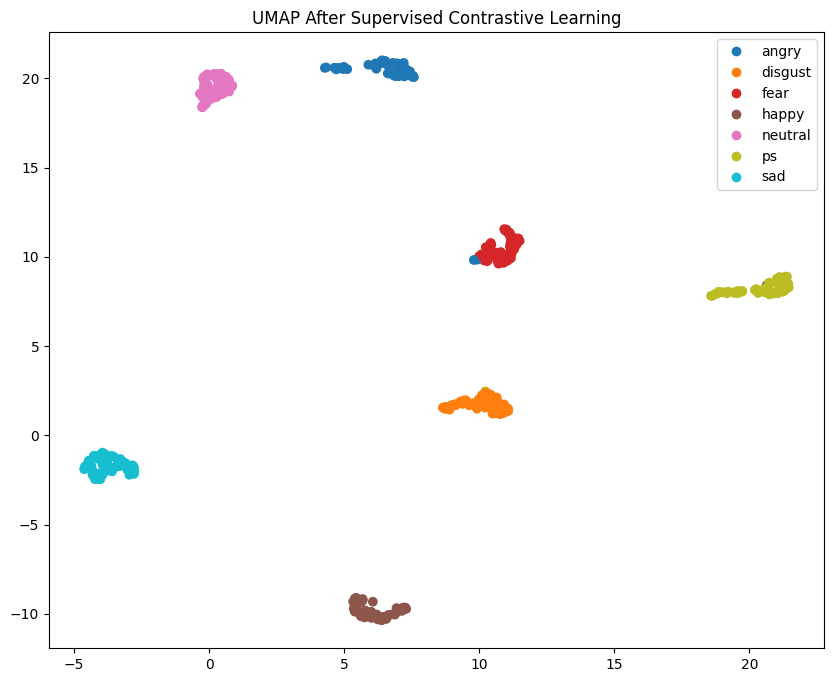

In [105]:
# ============================================================
# UMAP AFTER CONTRASTIVE LEARNING
# ============================================================

reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

reduced_embeddings = reducer.fit_transform(
    contrastive_embeddings
)

plt.figure(figsize=(10,8))

scatter = plt.scatter(

    reduced_embeddings[:,0],

    reduced_embeddings[:,1],

    c=contrastive_labels,

    cmap="tab10"
)

plt.legend(

    handles=scatter.legend_elements()[0],

    labels=id2label.values()
)

plt.title(
    "UMAP After Supervised Contrastive Learning"
)

plt.show()

## RESULTS

In [106]:
# ============================================================
# CREATE RESULTS DIRECTORY
# ============================================================

import os

RESULTS_DIR = "speech_pipeline_results"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

print("Results Directory Created")

Results Directory Created


In [107]:
# ============================================================
# GENERATE FINAL TEST PREDICTIONS
# ============================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for batch in tqdm(test_loader):

        input_values = batch["input_values"].to(device)

        labels = batch["label"].to(device)

        (
            logits,
            pooled,
            projected_embeddings,
            attention_weights
        ) = model(input_values)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("Predictions Ready")

100%|██████████| 53/53 [00:12<00:00,  4.31it/s]

Predictions Ready


In [108]:
# ============================================================
# SAVE CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=id2label.values(),
    yticklabels=id2label.values()
)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Confusion Matrix")

plt.savefig(
    f"{RESULTS_DIR}/confusion_matrix.png",
    bbox_inches="tight"
)

plt.close()

print("Confusion Matrix Saved")

Confusion Matrix Saved


In [109]:
# ============================================================
# SAVE CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    target_names=list(id2label.values())
)

with open(
    f"{RESULTS_DIR}/classification_report.txt",
    "w"
) as f:

    f.write(report)

print("Classification Report Saved")

Classification Report Saved


In [110]:
# ============================================================
# SAVE UMAP PLOTS
# ============================================================

plt.figure(figsize=(10,8))

scatter = plt.scatter(

    reduced_embeddings[:,0],

    reduced_embeddings[:,1],

    c=contrastive_labels,

    cmap="tab10"
)

plt.legend(

    handles=scatter.legend_elements()[0],

    labels=id2label.values()
)

plt.title(
    "UMAP After Supervised Contrastive Learning"
)

plt.savefig(
    f"{RESULTS_DIR}/contrastive_umap.png",
    bbox_inches="tight"
)

plt.close()

print("UMAP Saved")

UMAP Saved


In [111]:
attention_to_plot = (
    attention_weights[0]   # FIRST SAMPLE
    .squeeze(-1)           # REMOVE LAST DIM
    .detach()
    .cpu()
    .numpy()
)

# ============================================================
# SAVE ATTENTION VISUALIZATION
# ============================================================

plt.figure(figsize=(14,4))

plt.plot(attention_to_plot)

plt.title(
    "Attention Weight Visualization"
)

plt.xlabel("Temporal Frames")

plt.ylabel("Attention Importance")

plt.savefig(
    f"{RESULTS_DIR}/attention_visualization.png",
    bbox_inches="tight"
)

plt.close()

print("Attention Visualization Saved")

Attention Visualization Saved


In [112]:
# ============================================================
# SAVE ABLATION RESULTS
# ============================================================

ablation_results.to_csv(
    f"{RESULTS_DIR}/pooling_ablation_results.csv",
    index=False
)

print("Ablation Results Saved")

Ablation Results Saved


In [113]:
# ============================================================
# SAVE EMBEDDINGS
# ============================================================

np.save(
    f"{RESULTS_DIR}/contrastive_embeddings.npy",
    contrastive_embeddings
)

np.save(
    f"{RESULTS_DIR}/contrastive_labels.npy",
    contrastive_labels
)

print("Embeddings Saved")

Embeddings Saved


In [114]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

torch.save(

    model.state_dict(),

    f"{RESULTS_DIR}/wavlm_contrastive_model.pth"
)

print("Model Saved")

Model Saved


In [115]:
# ============================================================
# SAVE FINAL METRICS
# ============================================================

metrics_summary = {

    "Test Accuracy": test_acc,

    "Test Macro F1": test_macro_f1,

    "Test Weighted F1": test_weighted_f1
}

metrics_df = pd.DataFrame(
    [metrics_summary]
)

metrics_df.to_csv(
    f"{RESULTS_DIR}/final_metrics.csv",
    index=False
)

print("Metrics Saved")

Metrics Saved


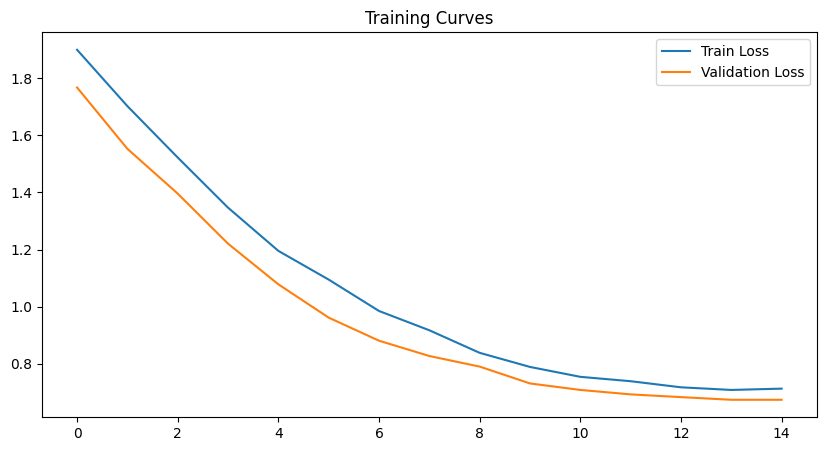

Training Curves Saved


In [116]:
# ============================================================
# SAVE TRAINING CURVES
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.title("Training Curves")

plt.savefig(
    f"{RESULTS_DIR}/training_curves.png",
    bbox_inches="tight"
)

plt.show()

plt.close()

print("Training Curves Saved")

In [117]:
# ============================================================
# CREATE ZIP FILE
# ============================================================

import shutil

shutil.make_archive(

    "speech_pipeline_results",

    "zip",

    RESULTS_DIR
)

print("ZIP File Created")

ZIP File Created


In [124]:
# ============================================================
# FULL DATASET
# ============================================================

full_dataset = TESSDataset(

    df,

    feature_extractor
)

print(len(full_dataset))

# ============================================================
# EXTRACT FULL SPEECH EMBEDDINGS
# ============================================================

full_loader = DataLoader(

    full_dataset,

    batch_size=32,

    shuffle=False
)

model.eval()

all_embeddings = []

all_labels = []

with torch.no_grad():

    for batch in tqdm(full_loader):

        input_values = batch[
            "input_values"
        ].to(device)

        labels = batch[
            "label"
        ].to(device)

        (
            logits,
            pooled,
            projected_embeddings,
            attention_weights
        ) = model(input_values)

        all_embeddings.append(

            projected_embeddings.cpu().numpy()
        )

        all_labels.extend(

            labels.cpu().numpy()
        )

all_embeddings = np.concatenate(
    all_embeddings
)

all_labels = np.array(
    all_labels
)

print(all_embeddings.shape)

print(all_labels.shape)

2800


100%|██████████| 88/88 [01:45<00:00,  1.20s/it]

(2800, 128)
(2800,)


In [125]:
# ============================================================
# SAVE FULL SPEECH EMBEDDINGS
# ============================================================

np.save(

    "full_speech_embeddings.npy",

    all_embeddings
)

np.save(

    "full_speech_labels.npy",

    all_labels
)

print("Full Speech Embeddings Saved")

Full Speech Embeddings Saved
